In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.graphics import tsaplots
from statsmodels.tsa import seasonal
from statsmodels.stats import diagnostic

## Overview

In [2]:
df = pd.read_csv("data/hvac_demand.csv", parse_dates=["Time"], index_col=["Time"])
df.head()


,air_pressure,air_temperature,relative_humidity,wind_speed,solar_irridiation,total_cloud_cover_percent,electricity_demand_values,heat_demand_values
Time,,,,,,,,
2010-12-01 00:00:00,729.7,25.0,85.0,5.0,0,0.00,289.567557,432.940036
2010-12-01 01:00:00,729.4,27.8,77.0,7.0,0,0.00,260.168520,473.935901
2010-12-01 02:00:00,728.9,33.3,62.0,7.0,0,0.25,247.273585,483.278761
2010-12-01 03:00:00,731.6,32.2,62.0,2.0,0,0.50,257.955878,545.921252
2010-12-01 04:00:00,732.6,22.8,96.0,3.0,0,0.25,258.255081,550.526112


In [3]:
df.index


DatetimeIndex(['2010-12-01 00:00:00', '2010-12-01 01:00:00',
               '2010-12-01 02:00:00', '2010-12-01 03:00:00',
               '2010-12-01 04:00:00', '2010-12-01 05:00:00',
               '2010-12-01 06:00:00', '2010-12-01 07:00:00',
               '2010-12-01 08:00:00', '2010-12-01 09:00:00',
               ...
               '2018-11-28 14:00:00', '2018-11-28 15:00:00',
               '2018-11-28 16:00:00', '2018-11-28 17:00:00',
               '2018-11-28 18:00:00', '2018-11-28 19:00:00',
               '2018-11-28 20:00:00', '2018-11-28 21:00:00',
               '2018-11-28 22:00:00', '2018-11-28 23:00:00'],
              dtype='datetime64[ns]', name='Time', length=70080, freq=None)

In [4]:
df.describe()


,air_pressure,air_temperature,relative_humidity,wind_speed,solar_irridiation,total_cloud_cover_percent,electricity_demand_values,heat_demand_values
count,70080.000000,70080.000000,70080.000000,70080.000000,70080.000000,70080.000000,70080.000000,70080.000000
mean,734.587334,17.874431,60.645077,4.830608,257.293094,0.323900,393.894392,263.551003
std,5.006131,10.669905,21.979472,2.581267,258.725788,0.387351,239.177728,314.720551
min,716.500000,-14.400000,4.000000,0.000000,0.000000,0.000000,112.947618,0.000000
25%,731.400000,10.000000,43.000000,3.000000,0.000000,0.000000,227.708651,0.000000
50%,734.200000,18.900000,61.000000,5.000000,299.500000,0.000000,323.095501,137.430266
75%,737.500000,25.600000,79.000000,6.000000,499.000000,0.750000,476.911512,448.333458
max,757.500000,43.300000,100.000000,26.000000,699.000000,1.000000,1592.893206,1529.168786


In [5]:
def normalize(df):
    return (df - df.mean()) / df.std()


## Time Scales

### Yearly

In [6]:
df_yearly = df.resample("M").mean().replace(0, np.nan)
df_yearly.describe()


/var/folders/py/n14256yd5r5ddms88x9bvsv40000gn/T/ipykernel_62013/3716378456.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_yearly = df.resample("M").mean().replace(0, np.nan)


,air_pressure,air_temperature,relative_humidity,wind_speed,solar_irridiation,total_cloud_cover_percent,electricity_demand_values,heat_demand_values
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,95.000000
mean,734.592965,17.858262,60.670624,4.830213,257.277128,0.323979,393.402655,267.126121
std,1.330841,5.293002,6.097872,0.409669,3.162674,0.052333,100.343157,262.104137
min,731.217876,8.594643,44.169355,4.010753,250.597222,0.223790,241.873205,0.459760
25%,733.545262,12.725739,56.462366,4.600739,255.094680,0.289504,309.342386,61.268401
50%,734.653898,17.567809,61.470789,4.838351,257.722222,0.316632,400.478978,173.332796
75%,735.614029,23.345853,64.999328,5.101815,259.646315,0.348949,444.473026,440.162174
max,737.676613,26.955108,71.988889,5.655172,263.361111,0.478111,582.306090,813.386588


In [7]:
df_yearly.pct_change(fill_method=None).mul(100).describe()


,air_pressure,air_temperature,relative_humidity,wind_speed,solar_irridiation,total_cloud_cover_percent,electricity_demand_values,heat_demand_values
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,93.000000
mean,0.001543,20.001688,0.712253,0.796634,-0.005611,2.998146,3.767417,1007.694802
std,0.334462,71.148270,11.739757,13.546722,1.767145,24.912106,29.675270,3543.055581
min,-0.705396,-63.387474,-32.295787,-28.290491,-4.523371,-48.001339,-32.213490,-94.449954
25%,-0.279858,-44.010800,-6.692726,-10.116350,-1.236170,-14.975291,-17.455985,-47.957869
50%,0.007685,-1.227256,0.924030,0.669860,-0.164157,-2.278630,-6.823303,-42.482888
75%,0.269253,90.043062,8.151248,11.951849,1.168951,14.254715,24.485525,86.090226
max,0.608390,181.162577,31.474043,30.938746,4.287562,64.896568,77.931596,13383.721726


[Text(0, 0.5, 'Change (%)')]

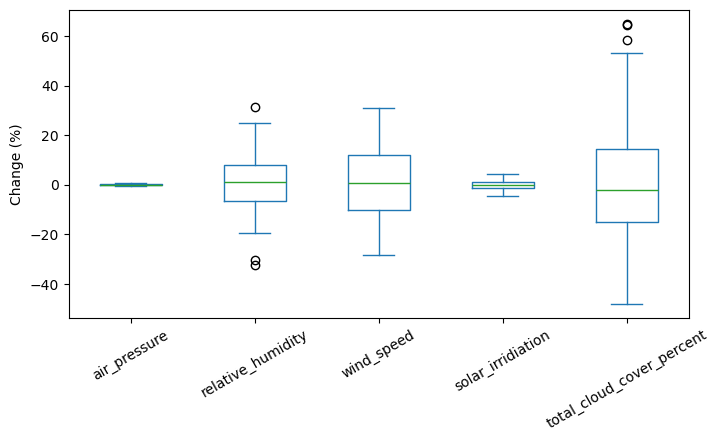

In [8]:
_, ax = plt.subplots(figsize=(8, 4))

df_yearly.drop(
    columns=["air_temperature", "electricity_demand_values", "heat_demand_values"]
).pct_change(fill_method=None).mul(100).plot(ax=ax, kind="box")
plt.setp(ax.get_xticklabels(), rotation=30)
ax.set(ylabel="Change (%)")


In [9]:
df_yearly_selected = df_yearly.drop(
    columns=[
        "air_pressure",
        "solar_irridiation",
        "electricity_demand_values",
        "heat_demand_values",
    ]
)
df_yearly_selected.describe()


,air_temperature,relative_humidity,wind_speed,total_cloud_cover_percent
count,96.000000,96.000000,96.000000,96.000000
mean,17.858262,60.670624,4.830213,0.323979
std,5.293002,6.097872,0.409669,0.052333
min,8.594643,44.169355,4.010753,0.223790
25%,12.725739,56.462366,4.600739,0.289504
50%,17.567809,61.470789,4.838351,0.316632
75%,23.345853,64.999328,5.101815,0.348949
max,26.955108,71.988889,5.655172,0.478111


[Text(0, 0.5, 'Log value')]

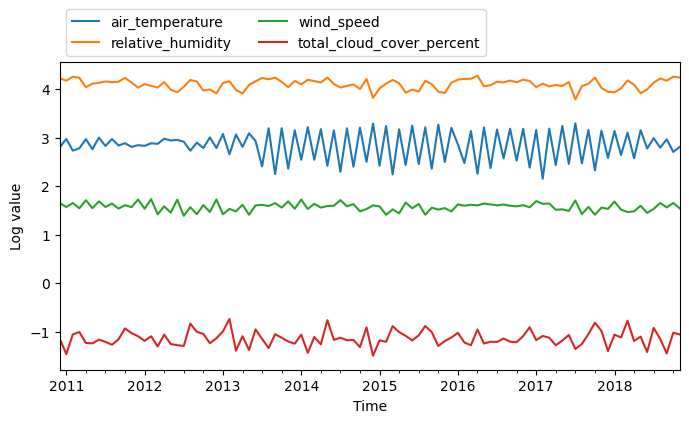

In [10]:
_, ax = plt.subplots(figsize=(8, 4))

np.log(df_yearly_selected).plot(ax=ax)
ax.legend(ncol=2, loc=(0.01, 1.02))
ax.set(ylabel="Log value")


### Monthly

In [11]:
df_monthly = df.query("'2010-12-01' <= Time < '2011-12-01'").resample("D").mean()
df_monthly.describe()


,air_pressure,air_temperature,relative_humidity,wind_speed,solar_irridiation,total_cloud_cover_percent,electricity_demand_values,heat_demand_values
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,734.968151,17.584247,64.554224,4.990753,257.491324,0.315804,393.911974,263.545495
std,3.239983,8.730223,10.546010,0.910687,15.976767,0.191836,136.162892,297.783528
min,725.720833,-2.366667,30.791667,2.750000,203.750000,0.000000,212.750667,0.000000
25%,732.891667,11.137500,57.625000,4.416667,246.708333,0.166667,284.305578,13.364915
50%,734.787500,17.891667,64.166667,5.000000,257.750000,0.281250,364.535916,139.120520
75%,736.862500,25.841667,72.083333,5.583333,268.208333,0.427083,456.617784,446.239021
max,747.420833,33.908333,88.875000,7.666667,309.708333,0.937500,1019.692819,1188.960791


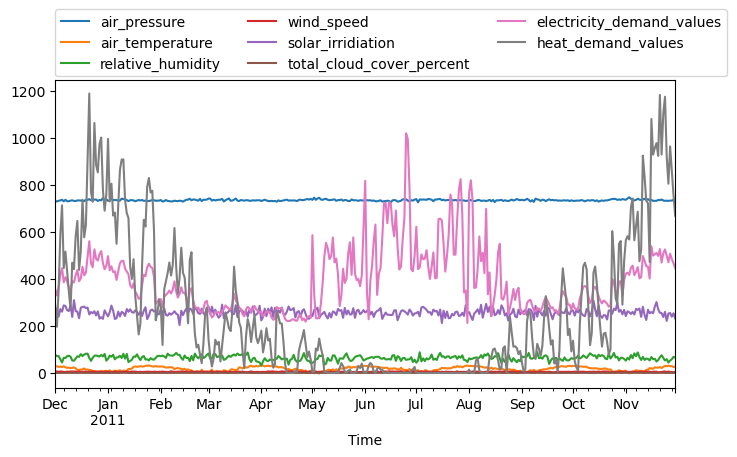

In [12]:
_, ax = plt.subplots(figsize=(8, 4))

df_monthly.plot(ax=ax)
ax.legend(ncol=3, loc=(0, 1.01))


In [13]:
df_monthly.drop(
    columns=[
        "air_pressure",
        "total_cloud_cover_percent",
        "electricity_demand_values",
        "heat_demand_values",
    ]
).pct_change(fill_method=None).mul(100).describe()


,air_temperature,relative_humidity,wind_speed,solar_irridiation
count,364.000000,364.000000,364.000000,364.000000
mean,-7.191053,1.743549,3.078604,0.369430
std,420.168439,19.076381,25.136407,9.084158
min,-7482.352941,-53.370166,-61.202186,-21.780303
25%,-12.788655,-10.841082,-15.747040,-6.369270
50%,-1.577484,1.513703,0.724790,0.227140
75%,11.521458,13.263190,20.368304,7.093981
max,2014.743590,66.509062,90.361446,29.918200


[Text(0, 0.5, 'Change (%)')]

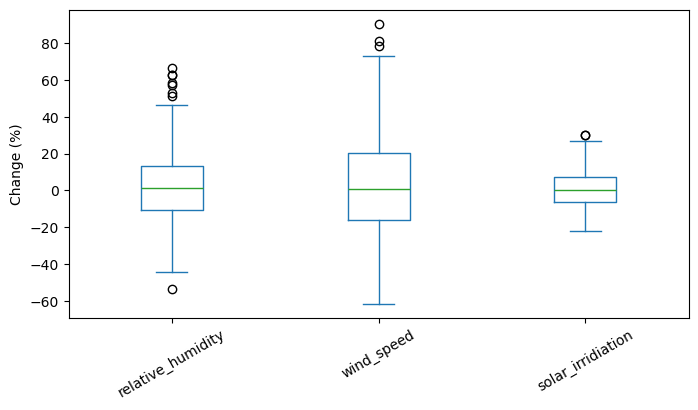

In [14]:
_, ax = plt.subplots(figsize=(8, 4))

df_monthly.drop(
    columns=[
        "air_pressure",
        "air_temperature",
        "total_cloud_cover_percent",
        "electricity_demand_values",
        "heat_demand_values",
    ]
).pct_change(fill_method=None).mul(100).plot(ax=ax, kind="box")
plt.setp(ax.get_xticklabels(), rotation=30)
ax.set(ylabel="Change (%)")


In [15]:
df_monthly_cols = df_monthly.columns.drop(
    [
        "air_pressure",
        "heat_demand_values",
        "electricity_demand_values",
    ]
)
df_monthly_selected = df_monthly[df_monthly_cols]
np.log(df_monthly_selected).describe()


/Users/integzz/.conda/envs/kaggle/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/Users/integzz/.conda/envs/kaggle/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/integzz/.conda/envs/kaggle/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,air_temperature,relative_humidity,wind_speed,solar_irridiation,total_cloud_cover_percent
count,360.000000,365.000000,365.000000,365.000000,365.000000
mean,2.707955,4.153370,1.590460,5.549059,-inf
std,0.688630,0.171643,0.187526,0.062259,NaN
min,-0.590290,3.427244,1.011601,5.316894,-inf
25%,2.418886,4.053957,1.485385,5.508207,-1.791759
50%,2.894283,4.161484,1.609438,5.551990,-1.268511
75%,3.254283,4.277823,1.719786,5.591764,-0.850776
max,3.523661,4.487231,2.036882,5.735631,-0.064539


/Users/integzz/.conda/envs/kaggle/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/Users/integzz/.conda/envs/kaggle/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


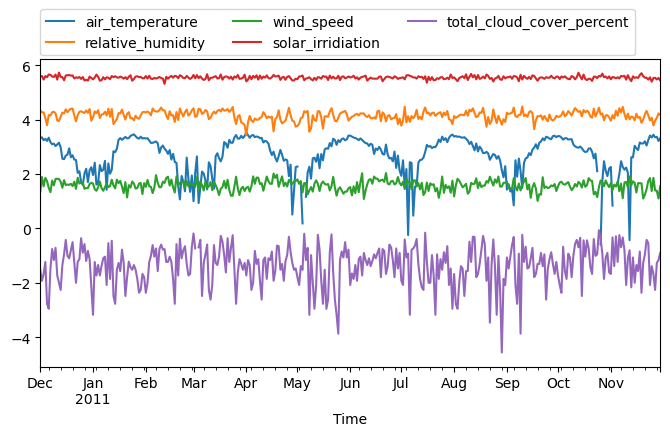

In [16]:
_, ax = plt.subplots(figsize=(8, 4))

np.log(df_monthly_selected).plot(ax=ax)
ax.legend(ncol=3, loc=(0, 1.01))


## Seasonality

### Yearly

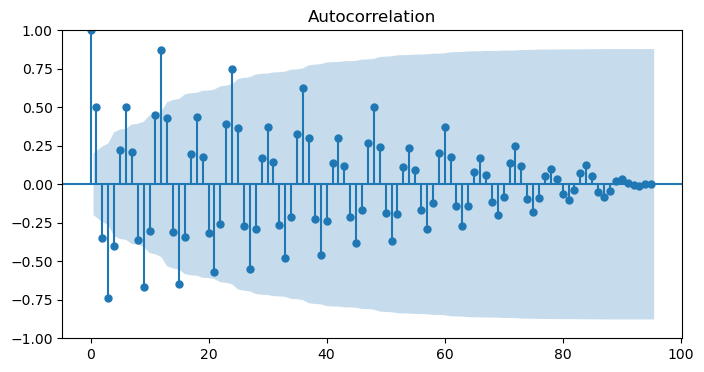

In [17]:
_, ax = plt.subplots(figsize=(8, 4))

yacf = tsaplots.plot_acf(df_yearly["electricity_demand_values"], lags=95, ax=ax)


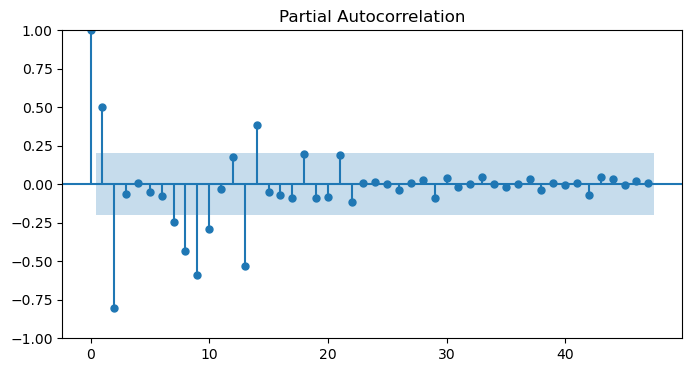

In [18]:
_, ax = plt.subplots(figsize=(8, 4))

ypacf = tsaplots.plot_pacf(df_yearly["electricity_demand_values"], lags=47, ax=ax)


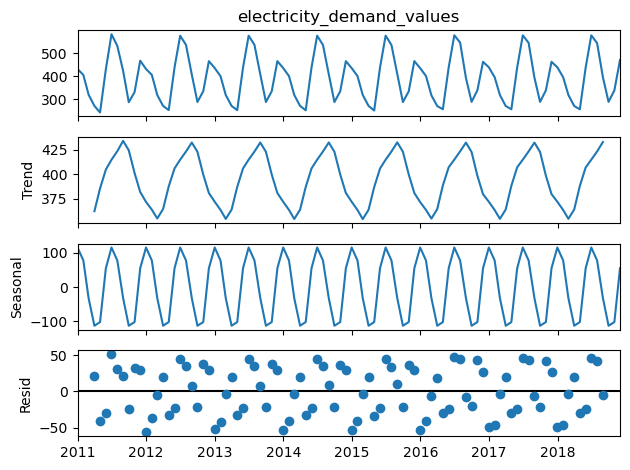

In [19]:
df_yearly_season = seasonal.seasonal_decompose(df_yearly["electricity_demand_values"], period=6).plot()


### Monthly

[None, None, None, None, None, None, None, None, None, None, None, None]

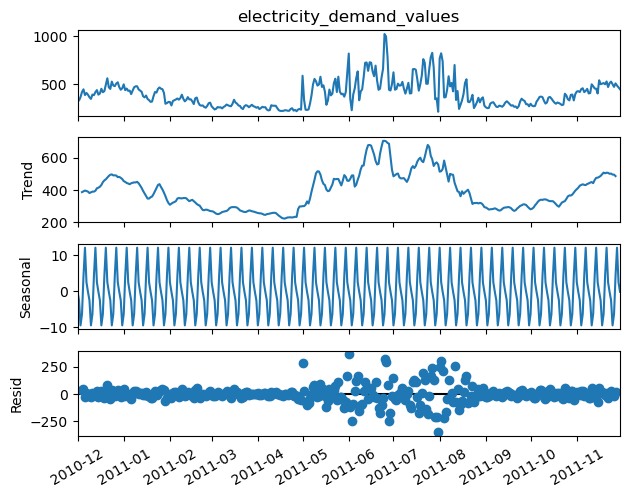

In [20]:
df_monthly_season = seasonal.seasonal_decompose(df_monthly["electricity_demand_values"], period=7).plot()

plt.setp(plt.gca().get_xticklabels(), rotation=30)


## Regression

[Text(0, 0.5, 'Squared Change')]

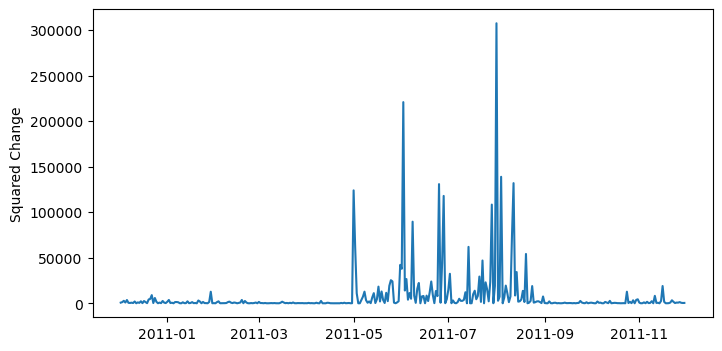

In [21]:
electricity_diff = df_monthly["electricity_demand_values"].diff().dropna()

_, ax = plt.subplots(figsize=(8, 4))
ax.plot(electricity_diff**2)
ax.set(ylabel="Squared Change")


In [22]:
lag_lst = [1, 2, 3, 4, 5]
for lag in lag_lst:
    alm = diagnostic.acorr_lm(electricity_diff, nlags=lag)[:2]
    print(alm)


(1.1815003923471168, 0.277050757066256)
(13.775864871423913, 0.001020020620501912)
(63.330997144075525, 1.1410349970194413e-13)
(74.3679506955595, 2.7107273161259856e-15)
(90.14265364394943, 6.2712993947131125e-18)


In [23]:
diagnostic.acorr_ljungbox(electricity_diff**2, lags=lag_lst, boxpierce=True, return_df=True)


,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,6.718942,9.539421e-03,6.663869,9.838710e-03
2,10.046488,6.583135e-03,9.955048,6.891102e-03
3,55.972784,4.257492e-12,55.253936,6.060924e-12
4,57.782043,8.478706e-12,57.033535,1.217290e-11
5,57.870641,3.344795e-11,57.120438,4.775998e-11
